In [1]:
!pip install pandas nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 1.3 MB/s eta 0:00:01
   -------------------- ------------------- 0.8/1.5 MB 1.5 MB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.5 MB/s  0:00:01


In [29]:
import os
import re
import pandas as pd
import nltk

In [41]:
nltk.download("vader_lexicon")
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\vetri\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vetri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\vetri\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [42]:
input_folder = r"reddit_dataset"          # folder containing original CSV files
cleaned_folder = r"reddit_cleaned_dataset" # folder for cleaned CSV files

os.makedirs(cleaned_folder, exist_ok=True)

print("Input folder:", input_folder)
print("Output folder:", cleaned_folder)

Input folder: reddit_dataset
Output folder: reddit_cleaned_dataset


In [43]:
def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # remove urls
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # remove reddit style remnants if any
    text = re.sub(r"/r/\w+", " ", text)
    text = re.sub(r"/u/\w+", " ", text)
    
    # remove HTML entities
    text = text.replace("&amp;", "and")
    text = text.replace("&lt;", " ")
    text = text.replace("&gt;", " ")
    text = text.replace("&quot;", " ")
    
    # fix weird apostrophe spacing like: don t -> dont
    text = re.sub(r"\b(\w+)\s+(\w+)\b", lambda m: m.group(0), text)
    
    # remove extra non-text symbols but keep sentence punctuation
    text = re.sub(r"[^A-Za-z0-9.,!?;:'\"()\-\s]", " ", text)
    
    # collapse repeated punctuation
    text = re.sub(r"([.,!?;]){2,}", r"\1", text)
    
    # collapse spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [44]:
def fix_broken_contractions(text):
    contractions = {
        r"\bi m\b": "i'm",
        r"\bdon t\b": "don't",
        r"\bcan t\b": "can't",
        r"\bwon t\b": "won't",
        r"\bisn t\b": "isn't",
        r"\baren t\b": "aren't",
        r"\bwasn t\b": "wasn't",
        r"\bweren t\b": "weren't",
        r"\bshouldn t\b": "shouldn't",
        r"\bcouldn t\b": "couldn't",
        r"\bwouldn t\b": "wouldn't",
        r"\bdidn t\b": "didn't",
        r"\bdoesn t\b": "doesn't",
        r"\bhaven t\b": "haven't",
        r"\bhasn t\b": "hasn't",
        r"\bhadn t\b": "hadn't",
        r"\bit s\b": "it's",
        r"\bthat s\b": "that's",
        r"\bthere s\b": "there's",
        r"\bwhat s\b": "what's",
        r"\bwho s\b": "who's",
        r"\byou re\b": "you're",
        r"\bwe re\b": "we're",
        r"\bthey re\b": "they're",
        r"\bi ve\b": "i've",
        r"\bwe ve\b": "we've",
        r"\bthey ve\b": "they've",
        r"\bi ll\b": "i'll",
        r"\byou ll\b": "you'll",
        r"\bhe s\b": "he's",
        r"\bshe s\b": "she's",
        r"\bi d\b": "i'd",
        r"\byou d\b": "you'd",
        r"\bdoesnt\b": "doesn't",
        r"\bdont\b": "don't",
        r"\bcant\b": "can't",
        r"\bwont\b": "won't",
        r"\bisnt\b": "isn't",
        r"\barent\b": "aren't"
    }
    
    text = text.lower()
    for pattern, replacement in contractions.items():
        text = re.sub(pattern, replacement, text)
    
    return text

In [45]:
def is_useful_text(text, min_chars=30):
    if not text or pd.isna(text):
        return False
    
    text = str(text).strip()
    
    if len(text) < min_chars:
        return False
    
    # reject text with too few words
    if len(text.split()) < 6:
        return False
    
    return True

In [46]:
possible_text_columns = [
    "review_text",
    "cleaned_review_text",
    "text",
    "body",
    "comment",
    "review",
    "selftext",
    "content"
]

possible_laptop_columns = [
    "laptop_name",
    "product_name",
    "model_name",
    "name"
]

def choose_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

In [47]:
for filename in os.listdir(input_folder):
    if not filename.endswith(".csv"):
        continue
    
    file_path = os.path.join(input_folder, filename)
    
    try:
        df = pd.read_csv(file_path)
        print(f"\nProcessing: {filename}")
        print("Original rows:", len(df))
        
        text_col = choose_column(df, possible_text_columns)
        laptop_col = choose_column(df, possible_laptop_columns)
        
        if text_col is None:
            print(" No usable text column found. Skipping.")
            continue
        
        # keep only needed columns
        if laptop_col:
            clean_df = df[[laptop_col, text_col]].copy()
            clean_df.columns = ["laptop_name", "raw_text"]
        else:
            clean_df = df[[text_col]].copy()
            clean_df.columns = ["raw_text"]
            clean_df["laptop_name"] = filename.replace(".csv", "")
            clean_df = clean_df[["laptop_name", "raw_text"]]
        
        # clean text
        clean_df["cleaned_text"] = clean_df["raw_text"].astype(str).apply(clean_text)
        clean_df["cleaned_text"] = clean_df["cleaned_text"].apply(fix_broken_contractions)
        
        # remove useless rows
        clean_df = clean_df[clean_df["cleaned_text"].apply(is_useful_text)]
        
        # drop duplicates
        clean_df = clean_df.drop_duplicates(subset=["cleaned_text"]).reset_index(drop=True)
        
        # keep final columns only
        clean_df = clean_df[["laptop_name", "cleaned_text"]]
        
        output_path = os.path.join(cleaned_folder, filename)
        clean_df.to_csv(output_path, index=False, encoding="utf-8")
        
        print(" Cleaned rows:", len(clean_df))
        print(" Saved to:", output_path)
    
    except Exception as e:
        print(f" Error in {filename}: {e}")


Processing: all_reddit_cleaned.csv
Original rows: 31
 Cleaned rows: 29
 Saved to: reddit_cleaned_dataset\all_reddit_cleaned.csv

Processing: ASUS_ROG_Strix_G15.csv
Original rows: 254
 Cleaned rows: 190
 Saved to: reddit_cleaned_dataset\ASUS_ROG_Strix_G15.csv

Processing: ASUS_ROG_Strix_Scar_15.csv
Original rows: 235
 Cleaned rows: 186
 Saved to: reddit_cleaned_dataset\ASUS_ROG_Strix_Scar_15.csv

Processing: ASUS_ROG_Zephyrus_G14.csv
Original rows: 220
 Cleaned rows: 183
 Saved to: reddit_cleaned_dataset\ASUS_ROG_Zephyrus_G14.csv

Processing: ASUS_TUF_A15_FA506.csv
Original rows: 239
 Cleaned rows: 192
 Saved to: reddit_cleaned_dataset\ASUS_TUF_A15_FA506.csv

Processing: ASUS_TUF_F15_FX506.csv
Original rows: 241
 Cleaned rows: 194
 Saved to: reddit_cleaned_dataset\ASUS_TUF_F15_FX506.csv

Processing: ASUS_TUF_F15_FX507.csv
Original rows: 38
 Cleaned rows: 31
 Saved to: reddit_cleaned_dataset\ASUS_TUF_F15_FX507.csv

Processing: ASUS_VivoBook_15_X1502ZA.csv
Original rows: 157
 Cleaned row

In [48]:
cleaned_sample = os.path.join(cleaned_folder, os.listdir(cleaned_folder)[0])
df_cleaned_sample = pd.read_csv(cleaned_sample)
df_cleaned_sample.head(10)

,laptop_name,cleaned_text
0,ASUS VivoBook 15 X1502ZA,"location: aligarh, india (can come to delhi fo..."
1,ASUS VivoBook 15 X1502ZA,"i have a asus vivobook 15 x1502za-bq2346 , but..."
2,ASUS VivoBook 15 X1502ZA,should i buy this laptop for coding?
3,ASUS VivoBook 15 X1502ZA,i've seen a lot of people online complain abou...
4,ASUS VivoBook 15 X1502ZA,hey can anyone help me? my keyboard stops work...
5,ASUS VivoBook 15 X1502ZA,i got vivobook15 12500h 16gb ram varient. the ...
6,ASUS VivoBook 15 X1502ZA,i'll be using it for coding during my btech
7,ASUS VivoBook 15 X1502ZA,so i replaced my asus vivobook's battery but i...
8,ASUS VivoBook 15 X1502ZA,"i'm looking into buying this laptop, further s..."
9,ASUS VivoBook 15 X1502ZA,i have an asus vivobook 15 i7 x1502za f1502za ...


In [49]:
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize

sia = SentimentIntensityAnalyzer()

In [50]:
sentiment_folder = r"reddit_vader_results"
os.makedirs(sentiment_folder, exist_ok=True)

In [51]:
for filename in os.listdir(cleaned_folder):
    if not filename.endswith(".csv"):
        continue
    
    file_path = os.path.join(cleaned_folder, filename)
    df = pd.read_csv(file_path)
    
    all_results = []
    
    for _, row in df.iterrows():
        laptop_name = row["laptop_name"]
        text = str(row["cleaned_text"])
        
        sentences = sent_tokenize(text)
        
        for sentence in sentences:
            sentence = sentence.strip()
            if len(sentence) < 5:
                continue
            
            score = sia.polarity_scores(sentence)
            compound = score["compound"]
            
            if compound >= 0.05:
                sentiment = "positive"
            elif compound <= -0.05:
                sentiment = "negative"
            else:
                sentiment = "neutral"
            
            all_results.append({
                "laptop_name": laptop_name,
                "sentence": sentence,
                "compound_score": compound,
                "sentiment": sentiment
            })
    
    result_df = pd.DataFrame(all_results)
    
    output_path = os.path.join(sentiment_folder, filename)
    result_df.to_csv(output_path, index=False, encoding="utf-8")
    
    print(f"Saved sentiment file: {filename} | Rows: {len(result_df)}")

Saved sentiment file: all_reddit_cleaned.csv | Rows: 145
Saved sentiment file: ASUS_ROG_Strix_G15.csv | Rows: 1627
Saved sentiment file: ASUS_ROG_Strix_Scar_15.csv | Rows: 1903
Saved sentiment file: ASUS_ROG_Zephyrus_G14.csv | Rows: 1587
Saved sentiment file: ASUS_TUF_A15_FA506.csv | Rows: 1414
Saved sentiment file: ASUS_TUF_F15_FX506.csv | Rows: 1221
Saved sentiment file: ASUS_TUF_F15_FX507.csv | Rows: 186
Saved sentiment file: ASUS_VivoBook_15_X1502ZA.csv | Rows: 815
Saved sentiment file: ASUS_VivoBook_16_X1605.csv | Rows: 603
Saved sentiment file: ASUS_VivoBook_Go_15_E1504FA.csv | Rows: 1082
Saved sentiment file: ASUS_ZenBook_14_OLED.csv | Rows: 1171
Saved sentiment file: Dell_Alienware_m16.csv | Rows: 802
Saved sentiment file: Dell_G15_5520.csv | Rows: 352
Saved sentiment file: Dell_G15_5530.csv | Rows: 444
Saved sentiment file: Dell_G15_5530_RTX_4050.csv | Rows: 601
Saved sentiment file: Dell_G16.csv | Rows: 763
Saved sentiment file: Dell_Inspiron_14_5430.csv | Rows: 445
Saved sen

In [52]:
summary_rows = []

for filename in os.listdir(sentiment_folder):
    if not filename.endswith(".csv"):
        continue
    
    file_path = os.path.join(sentiment_folder, filename)
    df = pd.read_csv(file_path)
    
    positive_count = (df["sentiment"] == "positive").sum()
    negative_count = (df["sentiment"] == "negative").sum()
    neutral_count = (df["sentiment"] == "neutral").sum()
    
    summary_rows.append({
        "file_name": filename,
        "positive_sentences": positive_count,
        "negative_sentences": negative_count,
        "neutral_sentences": neutral_count,
        "total_sentences": len(df)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("reddit_vader_summary.csv", index=False)
summary_df

,file_name,positive_sentences,negative_sentences,neutral_sentences,total_sentences
0,all_reddit_cleaned.csv,55,20,70,145
1,ASUS_ROG_Strix_G15.csv,677,297,653,1627
2,ASUS_ROG_Strix_Scar_15.csv,747,336,820,1903
3,ASUS_ROG_Zephyrus_G14.csv,700,262,625,1587
4,ASUS_TUF_A15_FA506.csv,587,280,547,1414
5,ASUS_TUF_F15_FX506.csv,464,269,488,1221
6,ASUS_TUF_F15_FX507.csv,70,44,72,186
7,ASUS_VivoBook_15_X1502ZA.csv,350,134,331,815
8,ASUS_VivoBook_16_X1605.csv,281,89,233,603
9,ASUS_VivoBook_Go_15_E1504FA.csv,528,140,414,1082


In [53]:
aspects = {
    "battery": ["battery", "battery life", "charge", "charging"],
    "performance": ["performance", "speed", "fast", "slow", "lag"],
    "display": ["display", "screen", "panel", "brightness"],
    "keyboard": ["keyboard", "keys", "typing"],
    "touchpad": ["touchpad", "trackpad"],
    "thermals": ["heat", "heating", "temperature", "thermal", "fan"],
    "noise": ["noise", "fan noise", "loud", "silent"],
    "build": ["build", "build quality", "plastic", "metal"],
    "price": ["price", "cost", "expensive", "cheap"],
    "design": ["design", "look", "aesthetic"],
    "software": ["software", "armoury crate", "driver", "bios"]
}

In [54]:
def detect_aspect(sentence):
    sentence = sentence.lower()
    
    for aspect, keywords in aspects.items():
        for keyword in keywords:
            if keyword in sentence:
                return aspect
    
    return "other"

In [55]:
aspect_rows = []

for filename in os.listdir(sentiment_folder):
    
    if not filename.endswith(".csv"):
        continue
        
    file_path = os.path.join(sentiment_folder, filename)
    df = pd.read_csv(file_path)
    
    for _, row in df.iterrows():
        
        sentence = str(row["sentence"])
        sentiment = row["sentiment"]
        laptop = row["laptop_name"]
        
        aspect = detect_aspect(sentence)
        
        aspect_rows.append({
            "laptop": laptop,
            "sentence": sentence,
            "aspect": aspect,
            "sentiment": sentiment
        })

aspect_df = pd.DataFrame(aspect_rows)

aspect_df.head()

,laptop,sentence,aspect,sentiment
0,ASUS VivoBook 15 X1502ZA,"location: aligarh, india (can come to delhi fo...",display,positive
1,ASUS VivoBook 15 X1502ZA,performance is still very good thanks to the i...,performance,positive
2,ASUS VivoBook 15 X1502ZA,minor issues: one usb 2.0 port and the chargin...,battery,neutral
3,ASUS VivoBook 15 X1502ZA,all usb 3.0 ports work normally at full speed.,performance,neutral
4,ASUS VivoBook 15 X1502ZA,a cosmetic crack on the keyboard body (keyboar...,keyboard,neutral


In [56]:
aspect_df.to_csv("laptop_aspect_sentiment.csv", index=False)

In [57]:
aspect_summary = aspect_df.groupby(["laptop","aspect","sentiment"]).size().reset_index(name="count")

aspect_summary.head()

,laptop,aspect,sentiment,count
0,ASUS ROG Strix G15,battery,negative,20
1,ASUS ROG Strix G15,battery,neutral,35
2,ASUS ROG Strix G15,battery,positive,18
3,ASUS ROG Strix G15,build,negative,11
4,ASUS ROG Strix G15,build,neutral,17


In [58]:
aspect_pivot = aspect_summary.pivot_table(
    index=["laptop","aspect"],
    columns="sentiment",
    values="count",
    fill_value=0
)

aspect_pivot

sentiment                       negative  neutral  positive
laptop             aspect                                  
ASUS ROG Strix G15 battery          20.0     35.0      18.0
                   build            11.0     17.0      19.0
                   design            8.0     26.0      18.0
                   display          16.0     29.0      30.0
                   keyboard          7.0      7.0      13.0
...                                  ...      ...       ...
Lenovo Yoga Slim 6 performance       3.0      8.0       9.0
                   price             0.0      4.0      14.0
                   software          3.0      2.0       3.0
                   thermals          2.0      3.0       1.0
                   touchpad          4.0      1.0       5.0

[443 rows x 3 columns]

In [59]:
aspect_pivot["score"] = (
    aspect_pivot["positive"] - aspect_pivot["negative"]
) / (
    aspect_pivot["positive"] + aspect_pivot["negative"] + aspect_pivot["neutral"]
)

aspect_pivot

sentiment                       negative  neutral  positive     score
laptop             aspect                                            
ASUS ROG Strix G15 battery          20.0     35.0      18.0 -0.027397
                   build            11.0     17.0      19.0  0.170213
                   design            8.0     26.0      18.0  0.192308
                   display          16.0     29.0      30.0  0.186667
                   keyboard          7.0      7.0      13.0  0.222222
...                                  ...      ...       ...       ...
Lenovo Yoga Slim 6 performance       3.0      8.0       9.0  0.300000
                   price             0.0      4.0      14.0  0.777778
                   software          3.0      2.0       3.0  0.000000
                   thermals          2.0      3.0       1.0 -0.166667
                   touchpad          4.0      1.0       5.0  0.100000

[443 rows x 4 columns]

In [60]:
battery_comparison = aspect_pivot.xs("battery", level="aspect")

battery_comparison.sort_values("score", ascending=False)

sentiment,negative,neutral,positive,score
laptop,,,,
Lenovo LOQ 16,1.0,1.0,5.0,0.571429
HP Omen 16,0.0,8.0,8.0,0.500000
ASUS VivoBook Go 15 E1504FA,4.0,16.0,25.0,0.466667
HP Omen Transcend 14,6.0,11.0,26.0,0.465116
HP Pavilion Aero 13,6.0,16.0,28.0,0.440000
ASUS ROG Zephyrus G14,9.0,24.0,39.0,0.416667
HP 15s-fq Series,1.0,1.0,3.0,0.400000
Lenovo Yoga Slim 6,9.0,25.0,35.0,0.376812
ASUS VivoBook 16 X1605,12.0,19.0,35.0,0.348485


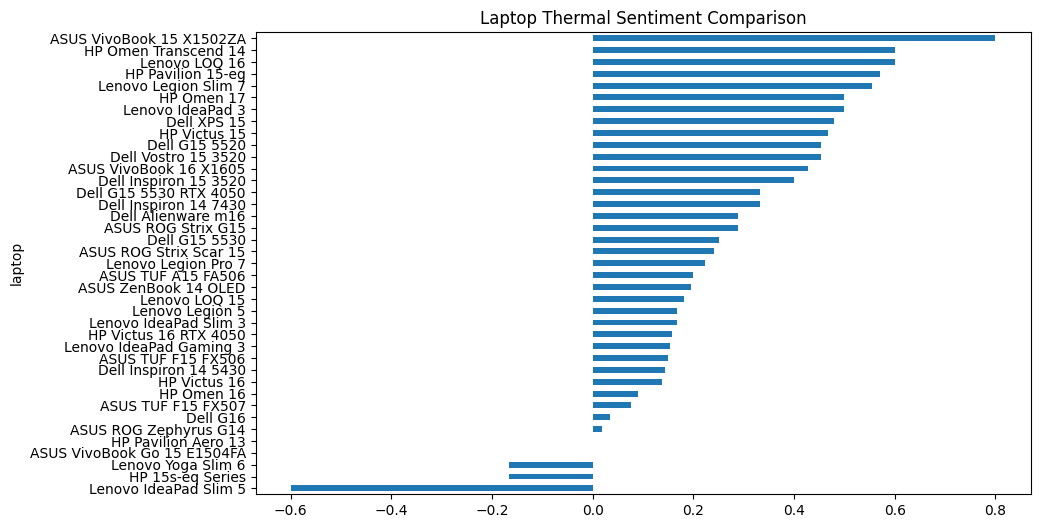

In [61]:
import matplotlib.pyplot as plt

thermals = aspect_pivot.xs("thermals", level="aspect")

thermals["score"].sort_values().plot(kind="barh", figsize=(10,6))

plt.title("Laptop Thermal Sentiment Comparison")
plt.show()

In [1]:
aspects = {
    "battery": [
        "battery", "battery life", "backup", "charge", "charging", "charger"
    ],
    "performance": [
        "performance", "fast", "slow", "lag", "smooth", "fps", "gaming", "multitasking",
        "benchmark", "cinebench", "rendering", "productivity"
    ],
    "thermals": [
        "heat", "heating", "hot", "temperature", "temps", "thermal", "thermals",
        "fan", "fan noise", "cooling", "overheating"
    ],
    "display": [
        "display", "screen", "panel", "brightness", "colors", "colour", "oled",
        "resolution", "refresh rate", "60hz", "120hz", "144hz", "240hz"
    ],
    "build_quality": [
        "build", "build quality", "plastic", "metal", "hinge", "durable", "sturdy",
        "body", "chassis"
    ],
    "keyboard": [
        "keyboard", "keys", "typing", "key travel", "backlit"
    ],
    "touchpad": [
        "touchpad", "trackpad"
    ],
    "audio": [
        "speaker", "speakers", "audio", "sound", "volume", "mic", "microphone"
    ],
    "price": [
        "price", "cost", "value", "worth", "expensive", "cheap", "deal", "money", "budget"
    ],
    "software": [
        "software", "driver", "drivers", "bios", "armoury crate", "ghelper", "windows",
        "bug", "bugs", "crash", "crashes", "update", "updates"
    ],
    "design": [
        "design", "look", "looks", "aesthetic", "rgb", "style", "portable", "weight", "thin", "light"
    ],
    "ram_storage": [
        "ram", "memory", "storage", "ssd", "hdd", "upgrade", "upgradable", "overclocking"
    ],
    "connectivity": [
        "wifi", "bluetooth", "port", "ports", "usb", "hdmi", "type c", "ethernet"
    ]
}

In [4]:
def detect_aspects(sentence, aspects_dict):
    sentence = str(sentence).lower()
    matched_aspects = []
    
    for aspect, keywords in aspects_dict.items():
        for keyword in keywords:
            if keyword in sentence:
                matched_aspects.append(aspect)
                break
    
    if not matched_aspects:
        matched_aspects.append("other")
    
    return matched_aspects

In [3]:
import os
import pandas as pd

sentiment_folder = r"reddit_vader_results"
aspect_output_folder = r"reddit_aspect_results"

os.makedirs(aspect_output_folder, exist_ok=True)

all_aspect_rows = []

for filename in os.listdir(sentiment_folder):
    if not filename.endswith(".csv"):
        continue
    
    file_path = os.path.join(sentiment_folder, filename)
    df = pd.read_csv(file_path)
    
    # safety check
    required_cols = {"laptop_name", "sentence", "sentiment"}
    if not required_cols.issubset(df.columns):
        print(f"Skipping {filename} - required columns missing")
        continue
    
    expanded_rows = []
    
    for _, row in df.iterrows():
        laptop_name = row["laptop_name"]
        sentence = str(row["sentence"])
        sentiment = row["sentiment"]
        compound_score = row.get("compound_score", None)
        
        detected_aspects = detect_aspects(sentence, aspects)
        
        for aspect in detected_aspects:
            expanded_rows.append({
                "laptop_name": laptop_name,
                "sentence": sentence,
                "aspect": aspect,
                "sentiment": sentiment,
                "compound_score": compound_score
            })
    
    aspect_df = pd.DataFrame(expanded_rows)
    
    output_path = os.path.join(aspect_output_folder, filename)
    aspect_df.to_csv(output_path, index=False)
    
    all_aspect_rows.extend(expanded_rows)
    print(f"Processed {filename} | Rows: {len(aspect_df)}")

all_aspect_df = pd.DataFrame(all_aspect_rows)
all_aspect_df.to_csv("all_laptops_aspect_sentiment.csv", index=False)

print("Done. Master file saved as all_laptops_aspect_sentiment.csv")

Processed all_reddit_cleaned.csv | Rows: 198
Processed ASUS_ROG_Strix_G15.csv | Rows: 2241
Processed ASUS_ROG_Strix_Scar_15.csv | Rows: 2664
Processed ASUS_ROG_Zephyrus_G14.csv | Rows: 2257
Processed ASUS_TUF_A15_FA506.csv | Rows: 2023
Processed ASUS_TUF_F15_FX506.csv | Rows: 1626
Processed ASUS_TUF_F15_FX507.csv | Rows: 275
Processed ASUS_VivoBook_15_X1502ZA.csv | Rows: 1122
Processed ASUS_VivoBook_16_X1605.csv | Rows: 953
Processed ASUS_VivoBook_Go_15_E1504FA.csv | Rows: 1903
Processed ASUS_ZenBook_14_OLED.csv | Rows: 1615
Processed Dell_Alienware_m16.csv | Rows: 1052
Processed Dell_G15_5520.csv | Rows: 513
Processed Dell_G15_5530.csv | Rows: 649
Processed Dell_G15_5530_RTX_4050.csv | Rows: 873
Processed Dell_G16.csv | Rows: 1075
Processed Dell_Inspiron_14_5430.csv | Rows: 630
Processed Dell_Inspiron_14_7430.csv | Rows: 618
Processed Dell_Inspiron_15_3520.csv | Rows: 1110
Processed Dell_Vostro_15_3520.csv | Rows: 371
Processed Dell_XPS_15.csv | Rows: 783
Processed HP_15s-eq_Series.cs

In [5]:
all_aspect_df.head(20)

,laptop_name,sentence,aspect,sentiment,compound_score
0,ASUS VivoBook 15 X1502ZA,"location: aligarh, india (can come to delhi fo...",display,positive,0.6369
1,ASUS VivoBook 15 X1502ZA,"location: aligarh, india (can come to delhi fo...",software,positive,0.6369
2,ASUS VivoBook 15 X1502ZA,"location: aligarh, india (can come to delhi fo...",ram_storage,positive,0.6369
3,ASUS VivoBook 15 X1502ZA,performance is still very good thanks to the i...,performance,positive,0.7485
4,ASUS VivoBook 15 X1502ZA,performance is still very good thanks to the i...,ram_storage,positive,0.7485
5,ASUS VivoBook 15 X1502ZA,minor issues: one usb 2.0 port and the chargin...,battery,neutral,0.0000
6,ASUS VivoBook 15 X1502ZA,minor issues: one usb 2.0 port and the chargin...,connectivity,neutral,0.0000
7,ASUS VivoBook 15 X1502ZA,all usb 3.0 ports work normally at full speed.,connectivity,neutral,0.0000
8,ASUS VivoBook 15 X1502ZA,a cosmetic crack on the keyboard body (keyboar...,build_quality,neutral,0.0000
9,ASUS VivoBook 15 X1502ZA,a cosmetic crack on the keyboard body (keyboar...,keyboard,neutral,0.0000


In [6]:
aspect_summary = (
    all_aspect_df
    .groupby(["laptop_name", "aspect", "sentiment"])
    .size()
    .reset_index(name="count")
)

aspect_summary.head(20)

,laptop_name,aspect,sentiment,count
0,ASUS ROG Strix G15,audio,negative,3
1,ASUS ROG Strix G15,audio,neutral,12
2,ASUS ROG Strix G15,audio,positive,17
3,ASUS ROG Strix G15,battery,negative,20
4,ASUS ROG Strix G15,battery,neutral,36
5,ASUS ROG Strix G15,battery,positive,19
6,ASUS ROG Strix G15,build_quality,negative,12
7,ASUS ROG Strix G15,build_quality,neutral,36
8,ASUS ROG Strix G15,build_quality,positive,33
9,ASUS ROG Strix G15,connectivity,negative,19


In [9]:
aspect_pivot = aspect_summary.pivot_table(
    index=["laptop_name", "aspect"],
    columns="sentiment",
    values="count",
    fill_value=0
).reset_index()



In [12]:

aspect_pivot.head(20)

sentiment,laptop_name,aspect,negative,neutral,positive,total_mentions,aspect_score
0,ASUS ROG Strix G15,audio,3.0,12.0,17.0,32.0,0.437500
1,ASUS ROG Strix G15,battery,20.0,36.0,19.0,75.0,-0.013333
2,ASUS ROG Strix G15,build_quality,12.0,36.0,33.0,81.0,0.259259
3,ASUS ROG Strix G15,connectivity,19.0,29.0,51.0,99.0,0.323232
4,ASUS ROG Strix G15,design,52.0,94.0,130.0,276.0,0.282609
5,ASUS ROG Strix G15,display,28.0,41.0,49.0,118.0,0.177966
6,ASUS ROG Strix G15,keyboard,11.0,11.0,21.0,43.0,0.232558
7,ASUS ROG Strix G15,other,121.0,314.0,270.0,705.0,0.211348
8,ASUS ROG Strix G15,performance,33.0,69.0,109.0,211.0,0.360190
9,ASUS ROG Strix G15,price,21.0,36.0,79.0,136.0,0.426471


In [13]:
for col in ["positive", "negative", "neutral"]:
    if col not in aspect_pivot.columns:
        aspect_pivot[col] = 0

In [14]:
aspect_pivot["total_mentions"] = (
    aspect_pivot["positive"] + aspect_pivot["negative"] + aspect_pivot["neutral"]
)

aspect_pivot["aspect_score"] = (
    aspect_pivot["positive"] - aspect_pivot["negative"]
) / aspect_pivot["total_mentions"]

In [15]:
aspect_pivot["total_mentions"] = (
    aspect_pivot["positive"] +
    aspect_pivot["negative"] +
    aspect_pivot["neutral"]
)

aspect_pivot["aspect_score"] = (
    aspect_pivot["positive"] -
    aspect_pivot["negative"]
) / aspect_pivot["total_mentions"]

In [16]:
aspect_pivot.head(20)

sentiment,laptop_name,aspect,negative,neutral,positive,total_mentions,aspect_score
0,ASUS ROG Strix G15,audio,3.0,12.0,17.0,32.0,0.437500
1,ASUS ROG Strix G15,battery,20.0,36.0,19.0,75.0,-0.013333
2,ASUS ROG Strix G15,build_quality,12.0,36.0,33.0,81.0,0.259259
3,ASUS ROG Strix G15,connectivity,19.0,29.0,51.0,99.0,0.323232
4,ASUS ROG Strix G15,design,52.0,94.0,130.0,276.0,0.282609
5,ASUS ROG Strix G15,display,28.0,41.0,49.0,118.0,0.177966
6,ASUS ROG Strix G15,keyboard,11.0,11.0,21.0,43.0,0.232558
7,ASUS ROG Strix G15,other,121.0,314.0,270.0,705.0,0.211348
8,ASUS ROG Strix G15,performance,33.0,69.0,109.0,211.0,0.360190
9,ASUS ROG Strix G15,price,21.0,36.0,79.0,136.0,0.426471


In [17]:
aspect_pivot[aspect_pivot["aspect"]=="battery"]

sentiment,laptop_name,aspect,negative,neutral,positive,total_mentions,aspect_score
1,ASUS ROG Strix G15,battery,20.0,36.0,19.0,75.0,-0.013333
15,ASUS ROG Strix Scar 15,battery,13.0,25.0,15.0,53.0,0.037736
29,ASUS ROG Zephyrus G14,battery,9.0,24.0,39.0,72.0,0.416667
43,ASUS TUF A15 FA506,battery,32.0,31.0,35.0,98.0,0.030612
57,ASUS TUF F15 FX506,battery,18.0,25.0,16.0,59.0,-0.033898
71,ASUS TUF F15 FX507,battery,3.0,3.0,3.0,9.0,0.000000
85,ASUS VivoBook 15 X1502ZA,battery,25.0,25.0,42.0,92.0,0.184783
99,ASUS VivoBook 16 X1605,battery,12.0,19.0,35.0,66.0,0.348485
113,ASUS VivoBook Go 15 E1504FA,battery,4.0,16.0,25.0,45.0,0.466667
127,ASUS ZenBook 14 OLED,battery,16.0,24.0,43.0,83.0,0.325301


In [18]:
aspect_pivot["total_mentions"] = (
    aspect_pivot["positive"] + aspect_pivot["negative"] + aspect_pivot["neutral"]
)

aspect_pivot["aspect_score"] = (
    aspect_pivot["positive"] - aspect_pivot["negative"]
) / aspect_pivot["total_mentions"]

In [19]:
aspect_pivot.to_csv("aspect_sentiment_summary.csv", index=False)
aspect_pivot.head(20)

sentiment,laptop_name,aspect,negative,neutral,positive,total_mentions,aspect_score
0,ASUS ROG Strix G15,audio,3.0,12.0,17.0,32.0,0.437500
1,ASUS ROG Strix G15,battery,20.0,36.0,19.0,75.0,-0.013333
2,ASUS ROG Strix G15,build_quality,12.0,36.0,33.0,81.0,0.259259
3,ASUS ROG Strix G15,connectivity,19.0,29.0,51.0,99.0,0.323232
4,ASUS ROG Strix G15,design,52.0,94.0,130.0,276.0,0.282609
5,ASUS ROG Strix G15,display,28.0,41.0,49.0,118.0,0.177966
6,ASUS ROG Strix G15,keyboard,11.0,11.0,21.0,43.0,0.232558
7,ASUS ROG Strix G15,other,121.0,314.0,270.0,705.0,0.211348
8,ASUS ROG Strix G15,performance,33.0,69.0,109.0,211.0,0.360190
9,ASUS ROG Strix G15,price,21.0,36.0,79.0,136.0,0.426471


In [20]:
battery_table = aspect_pivot[aspect_pivot["aspect"] == "battery"]

battery_table.sort_values("aspect_score", ascending=False)

sentiment,laptop_name,aspect,negative,neutral,positive,total_mentions,aspect_score
488,Lenovo LOQ 16,battery,1.0,1.0,5.0,7.0,0.571429
306,HP Omen 16,battery,0.0,8.0,8.0,16.0,0.500000
113,ASUS VivoBook Go 15 E1504FA,battery,4.0,16.0,25.0,45.0,0.466667
334,HP Omen Transcend 14,battery,6.0,11.0,26.0,43.0,0.465116
362,HP Pavilion Aero 13,battery,6.0,16.0,28.0,50.0,0.440000
29,ASUS ROG Zephyrus G14,battery,9.0,24.0,39.0,72.0,0.416667
295,HP 15s-fq Series,battery,1.0,1.0,3.0,5.0,0.400000
544,Lenovo Yoga Slim 6,battery,9.0,25.0,36.0,70.0,0.385714
99,ASUS VivoBook 16 X1605,battery,12.0,19.0,35.0,66.0,0.348485
530,Lenovo Legion Slim 7,battery,15.0,17.0,38.0,70.0,0.328571


In [21]:
import os
import shutil

In [22]:
source_folder = r"reddit_dataset"   # change this to your folder containing all CSV files
target_folder = r"grouped_laptop_dataset"

os.makedirs(target_folder, exist_ok=True)

In [23]:
groups = {
    "Group_1_Budget_Student": {
        "Row_1": [
            "ASUS_VivoBook_15_X1502ZA.csv",
            "HP_15s-fq_Series.csv",
            "Dell_Inspiron_15_3520.csv",
            "Lenovo_IdeaPad_Slim_3.csv"
        ],
        "Row_2": [
            "ASUS_VivoBook_Go_15_E1504FA.csv",
            "HP_15s-eq_Series.csv",
            "Dell_Vostro_15_3520.csv",
            "Lenovo_IdeaPad_3.csv"
        ]
    },

    "Group_2_Midrange_Thin_Light": {
        "Row_1": [
            "ASUS_VivoBook_16_X1605.csv",
            "HP_Pavilion_15-eg.csv",
            "Dell_Inspiron_14_5430.csv",
            "Lenovo_IdeaPad_Slim_5.csv"
        ],
        "Row_2": [
            "ASUS_ZenBook_14_OLED.csv",
            "HP_Pavilion_Aero_13.csv",
            "Dell_Inspiron_14_7430.csv",
            "Lenovo_Yoga_Slim_6.csv"
        ]
    },

    "Group_3_Entry_Gaming": {
        "Row_1": [
            "ASUS_TUF_F15_FX506.csv",
            "HP_Victus_15.csv",
            "Dell_G15_5520.csv",
            "Lenovo_IdeaPad_Gaming_3.csv"
        ],
        "Row_2": [
            "ASUS_TUF_A15_FA506.csv",
            "HP_Victus_16.csv",
            "Dell_G15_5530.csv",
            "Lenovo_LOQ_15.csv"
        ]
    },

    "Group_4_Mid_Gaming": {
        "Row_1": [
            "ASUS_TUF_F15_FX507.csv",
            "HP_Victus_16_RTX_4050.csv",
            "Dell_G15_5530_RTX_4050.csv",
            "Lenovo_LOQ_16.csv"
        ],
        "Row_2": [
            "ASUS_ROG_Strix_G15.csv",
            "HP_Omen_16.csv",
            "Dell_G16.csv",
            "Lenovo_Legion_5.csv"
        ]
    },

    "Group_5_Premium_Performance": {
        "Row_1": [
            "ASUS_ROG_Zephyrus_G14.csv",
            "HP_Omen_Transcend_14.csv",
            "Dell_XPS_15.csv",
            "Lenovo_Legion_Slim_7.csv"
        ],
        "Row_2": [
            "ASUS_ROG_Strix_Scar_15.csv",
            "HP_Omen_17.csv",
            "Dell_Alienware_m16.csv",
            "Lenovo_Legion_Pro_7.csv"
        ]
    }
}

In [24]:
for group_name, rows in groups.items():
    group_path = os.path.join(target_folder, group_name)
    os.makedirs(group_path, exist_ok=True)
    
    for row_name, files in rows.items():
        row_path = os.path.join(group_path, row_name)
        os.makedirs(row_path, exist_ok=True)
        
        for file_name in files:
            source_path = os.path.join(source_folder, file_name)
            target_path = os.path.join(row_path, file_name)
            
            if os.path.exists(source_path):
                shutil.copy2(source_path, target_path)
                print(f"Copied: {file_name} -> {group_name}/{row_name}")
            else:
                print(f"Missing: {file_name}")

Copied: ASUS_VivoBook_15_X1502ZA.csv -> Group_1_Budget_Student/Row_1
Copied: HP_15s-fq_Series.csv -> Group_1_Budget_Student/Row_1
Copied: Dell_Inspiron_15_3520.csv -> Group_1_Budget_Student/Row_1
Copied: Lenovo_IdeaPad_Slim_3.csv -> Group_1_Budget_Student/Row_1
Copied: ASUS_VivoBook_Go_15_E1504FA.csv -> Group_1_Budget_Student/Row_2
Copied: HP_15s-eq_Series.csv -> Group_1_Budget_Student/Row_2
Copied: Dell_Vostro_15_3520.csv -> Group_1_Budget_Student/Row_2
Copied: Lenovo_IdeaPad_3.csv -> Group_1_Budget_Student/Row_2
Copied: ASUS_VivoBook_16_X1605.csv -> Group_2_Midrange_Thin_Light/Row_1
Copied: HP_Pavilion_15-eg.csv -> Group_2_Midrange_Thin_Light/Row_1
Copied: Dell_Inspiron_14_5430.csv -> Group_2_Midrange_Thin_Light/Row_1
Copied: Lenovo_IdeaPad_Slim_5.csv -> Group_2_Midrange_Thin_Light/Row_1
Copied: ASUS_ZenBook_14_OLED.csv -> Group_2_Midrange_Thin_Light/Row_2
Copied: HP_Pavilion_Aero_13.csv -> Group_2_Midrange_Thin_Light/Row_2
Copied: Dell_Inspiron_14_7430.csv -> Group_2_Midrange_Thin_L

In [25]:
summary = []

for group_name, rows in groups.items():
    for row_name, files in rows.items():
        for file_name in files:
            exists = os.path.exists(os.path.join(source_folder, file_name))
            summary.append({
                "group": group_name,
                "row": row_name,
                "file_name": file_name,
                "status": "copied" if exists else "missing"
            })

import pandas as pd
summary_df = pd.DataFrame(summary)
summary_df

,group,row,file_name,status
0,Group_1_Budget_Student,Row_1,ASUS_VivoBook_15_X1502ZA.csv,copied
1,Group_1_Budget_Student,Row_1,HP_15s-fq_Series.csv,copied
2,Group_1_Budget_Student,Row_1,Dell_Inspiron_15_3520.csv,copied
3,Group_1_Budget_Student,Row_1,Lenovo_IdeaPad_Slim_3.csv,copied
4,Group_1_Budget_Student,Row_2,ASUS_VivoBook_Go_15_E1504FA.csv,copied
5,Group_1_Budget_Student,Row_2,HP_15s-eq_Series.csv,copied
6,Group_1_Budget_Student,Row_2,Dell_Vostro_15_3520.csv,copied
7,Group_1_Budget_Student,Row_2,Lenovo_IdeaPad_3.csv,copied
8,Group_2_Midrange_Thin_Light,Row_1,ASUS_VivoBook_16_X1605.csv,copied
9,Group_2_Midrange_Thin_Light,Row_1,HP_Pavilion_15-eg.csv,copied


In [26]:
group1_laptops = [
    "ASUS VivoBook 15 X1502ZA",
    "HP 15s-fq Series",
    "Dell Inspiron 15 3520",
    "Lenovo IdeaPad Slim 3"
]

battery_group1 = aspect_pivot[
    (aspect_pivot["laptop_name"].isin(group1_laptops)) &
    (aspect_pivot["aspect"] == "battery")
]

battery_group1.sort_values("aspect_score", ascending=False)

sentiment,laptop_name,aspect,negative,neutral,positive,total_mentions,aspect_score
295,HP 15s-fq Series,battery,1.0,1.0,3.0,5.0,0.400000
446,Lenovo IdeaPad Slim 3,battery,6.0,14.0,17.0,37.0,0.297297
239,Dell Inspiron 15 3520,battery,10.0,24.0,26.0,60.0,0.266667
85,ASUS VivoBook 15 X1502ZA,battery,25.0,25.0,42.0,92.0,0.184783


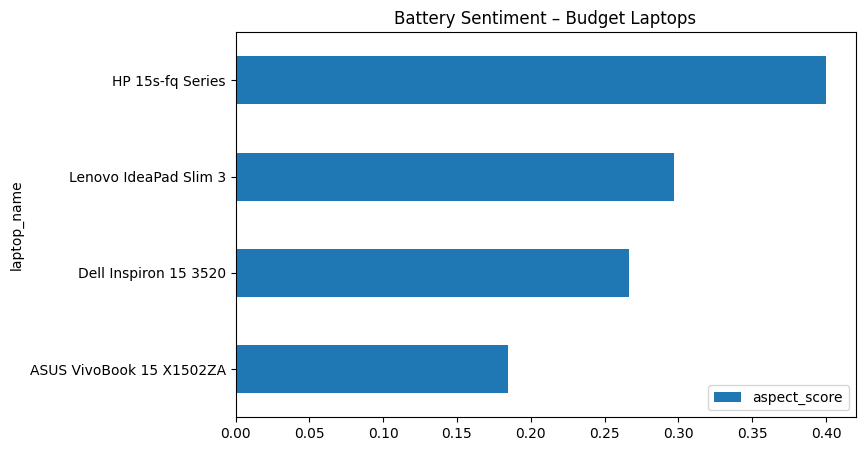

In [27]:
import matplotlib.pyplot as plt

battery_group1.sort_values("aspect_score").plot(
    x="laptop_name",
    y="aspect_score",
    kind="barh",
    figsize=(8,5)
)

plt.title("Battery Sentiment – Budget Laptops")
plt.show()